<center><div style="background-color: brown"><h1><font color=white face="georgia">Importing Libraries

In [1]:
# Data Preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from bs4 import BeautifulSoup
import re
from collections import Counter


# Data Visualization Modules
import matplotlib.pyplot as plt
import seaborn as sns

# Text Preprocessing
import nltk
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords
from nltk import sent_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

# Model Building and Training (ML models)
import time
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRFClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

# Neural Networks (DL model)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score

#Saving trained models
import pickle 

<center><div style="background-color: brown"><h1><font color=white face="georgia">Importing Data

In [2]:
spam_data = pd.read_csv('datasets/spam_assassin.csv')
spam_data

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0
...,...,...
5791,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0
5792,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0
5793,Received: from hq.pro-ns.net (localhost [127.0...,1
5794,From razor-users-admin@lists.sourceforge.net T...,0


<center><div style="background-color: brown"><h1><font color=white face="georgia">Data exploration

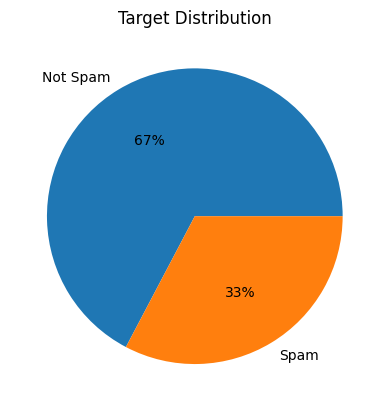

In [3]:
plt.pie(x=[spam_data['target'].value_counts()[0], spam_data['target'].value_counts()[1]], 
        labels=['Not Spam', 'Spam'], autopct='%.f%%')
plt.title('Target Distribution')
plt.show()

<h3><font face=verdona> As per the visualtization the data is fairly distributed for this specific Task

In [4]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5796 non-null   object
 1   target  5796 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 90.7+ KB


<h3><font color=yellow face=verdona><center> No null records

<center><div style="background-color: brown"><h1><font color=white face="georgia">Data cleaning

<h3><font color=yellow face=verdona><center>  Dropping Duplicates

In [5]:
print("Total duplicated rows : ",spam_data.duplicated().sum())

Total duplicated rows :  467


In [6]:
spam_data.drop_duplicates(keep='first', inplace=True)
spam_data.reset_index(drop=True, inplace=True)
spam_data

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0
...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0
5326,Received: from hq.pro-ns.net (localhost [127.0...,1
5327,From razor-users-admin@lists.sourceforge.net T...,0


<h3><font face=verdona> The text col data seems to have some kind of format

In [7]:
for i in range(5):
    print(spam_data['text'][i])

From ilug-admin@linux.ie Mon Jul 29 11:28:02 2002 Return-Path: <ilug-admin@linux.ie> Delivered-To: yyyy@localhost.netnoteinc.com Received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (Postfix) with ESMTP id A13D94414F for <jm@localhost>; Mon, 29 Jul 2002 06:25:11 -0400 (EDT) Received: from phobos [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for jm@localhost (single-drop); Mon, 29 Jul 2002 11:25:11 +0100 (IST) Received: from lugh.tuatha.org (root@lugh.tuatha.org [194.125.145.45]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g6RHn7i17130 for <jm-ilug@jmason.org>; Sat, 27 Jul 2002 18:49:07 +0100 Received: from lugh (root@localhost [127.0.0.1]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id SAA25016; Sat, 27 Jul 2002 18:45:03 +0100 X-Authentication-Warning: lugh.tuatha.org: Host root@localhost [127.0.0.1] claimed to be lugh Received: from mail1.mail.iol.ie (mail1.mail.iol.ie [194.125.2.192]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id SAA24977 fo

<h3><font face=verdona> Extracting important information using pattern

In [8]:
matches_set = list()

for i in range(len(spam_data)):
    matches = re.findall(r'\b\w+(?:-\w+)*: ', spam_data['text'][i])
    matches = [match.strip() for match in matches]
    matches = set(matches)
    matches_set.extend(list(matches))

counts = Counter(matches_set)
counts_dict = {x:y for x,y in counts.items() if y > 1000}
counts_data = pd.DataFrame()
counts_data['KEYS'] = pd.Series(counts_dict.keys())
counts_data['VALUES'] = pd.Series(counts_dict.values())
counts_data.sort_values(by='VALUES',ascending=False)

,KEYS,VALUES
6,Date:,5329
18,From:,5329
5,Subject:,5324
1,Received:,5196
15,To:,5161
7,Return-Path:,5130
13,Message-Id:,4958
2,Content-Type:,4589
17,Delivered-To:,4512
3,MIME-Version:,3764


<h3><font face=verdona> Creating dataframe for required features

In [9]:
reqd_features = ['From:', 'To:', 'Date:', 'Subject:', 'Received:', 'Content-Type:', 'Precedence:', 'Content-Transfer-Encoding:','List-Unsubscribe:','List-Subscribe:', 'In-Reply-To:','wrote:']

In [10]:
def return_dicts(email_text, reqd_features=reqd_features):
    data = dict()
    matches = re.findall(r'\b\w+(?:-\w+)*: ', email_text)
    matches = [match.strip() for match in matches]
    all_matches = ['From:']
    all_matches.extend(matches)
    split_text = re.split(r'\b\w+(?:-\w+)*: ', email_text)
    for i, j in zip(all_matches, split_text):
        for k in reqd_features:
            if k in i :
                data[i] = j
    return (
        data.get('From:', None),
        data.get('To:', None),
        data.get('Date:', None),
        data.get('Subject:', None),
        data.get('Received:', None),
        data.get('Content-Type:', None),
        data.get('Precedence:', None),
        data.get('Content-Transfer-Encoding:', None),
        data.get('List-Unsubscribe:', None),
        data.get('List-Subscribe:', None),
        data.get('In-Reply-To:', None),
        data.get('wrote:', None),
    )

In [11]:
spam_data[reqd_features] = pd.DataFrame(spam_data['text'].apply(return_dicts).tolist(), index=spam_data.index)
spam_data

,text,target,From:,To:,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,List-Unsubscribe:,List-Subscribe:,In-Reply-To:,wrote:
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,Conor Daly <conor.daly@oceanfree.net>,ILUG main list <ilug@linux.ie>,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0D443C91DCE9CD40B1C795BA222A729E018854FA@mile...,None
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"""irese"" <gort44@excite.com>",<chrbader@telecom.at>,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,None,None,None,None
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1,<5447q67@bolehmail.com>,"<fork-request@xent.com>, <fork@spamassassin.ta...","Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...","<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",None,None
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1,"""Rudy Chan""<dcm123@btamail.net.cn>",shandatch@netnoir.net,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,None,None,None,None
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0,Philip Reynolds <phil@redbrick.dcu.ie>,ilug@linux.ie,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.GA29167@chewie.compsoc.com>; f...,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0,"""Paul O'Neil"" <poneil@dbiassociates.net>",<ilug@linux.ie>,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0,CDale <cdale@techmonkeys.net>,bitbitch@magnesium.net,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,"<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",<3283394680.20021007145936@magnesium.net>,> > > So I get a check from Pac Bell today (SB...
5326,Received: from hq.pro-ns.net (localhost [127.0...,1,Ebargains <ebargains@reply.mb00.net>,cypherpunks@einstein.ssz.com,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None
5327,From razor-users-admin@lists.sourceforge.net T...,0,David Raistrick <drais@wow.atlasta.net>,"""Rose, Bobby"" <brose@med.wayne.edu>","Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,<https://example.sourceforge.net/lists/listinf...,<https://example.sourceforge.net/lists/listinf...,<D79A56AD131896448D0860DEE07CBE1F3BACA9@med-co...,> Use the sample-spam.txt from Spamassassin an...


In [12]:
print(spam_data.isna().sum())

text                             0
target                           0
From:                            0
To:                            168
Date:                            0
Subject:                         5
Received:                      133
Content-Type:                  740
Precedence:                   2226
Content-Transfer-Encoding:    2697
List-Unsubscribe:             2982
List-Subscribe:               3093
In-Reply-To:                  3690
wrote:                        4215
dtype: int64


<h4><font color=yellow face=verdona><hr>Analyzing "In-Reply-To" feature<hr></font>
<h4><font face=verdona>We know a replied email will never be classified as spam; only emails that are not replies can be marked as spam.

In [13]:
spam_data['Replied_mail'] = np.where(pd.isna(spam_data['In-Reply-To:']), 0, 1)
spam_data

,text,target,From:,To:,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,List-Unsubscribe:,List-Subscribe:,In-Reply-To:,wrote:,Replied_mail
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,Conor Daly <conor.daly@oceanfree.net>,ILUG main list <ilug@linux.ie>,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0D443C91DCE9CD40B1C795BA222A729E018854FA@mile...,None,1
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"""irese"" <gort44@excite.com>",<chrbader@telecom.at>,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,None,None,None,None,0
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1,<5447q67@bolehmail.com>,"<fork-request@xent.com>, <fork@spamassassin.ta...","Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...","<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",None,None,0
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1,"""Rudy Chan""<dcm123@btamail.net.cn>",shandatch@netnoir.net,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,None,None,None,None,0
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0,Philip Reynolds <phil@redbrick.dcu.ie>,ilug@linux.ie,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.GA29167@chewie.compsoc.com>; f...,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0,"""Paul O'Neil"" <poneil@dbiassociates.net>",<ilug@linux.ie>,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None,0
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0,CDale <cdale@techmonkeys.net>,bitbitch@magnesium.net,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,"<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",<3283394680.20021007145936@magnesium.net>,> > > So I get a check from Pac Bell today (SB...,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,1,Ebargains <ebargains@reply.mb00.net>,cypherpunks@einstein.ssz.com,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None,0
5327,From razor-users-admin@lists.sourceforge.net T...,0,David Raistrick <drais@wow.atlasta.net>,"""Rose, Bobby"" <brose@med.wayne.edu>","Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,<https://example.sourceforge.net/lists/listinf...,<https://example.sourceforge.net/lists/listinf...,<D79A56AD131896448D0860DEE07CBE1F3BACA9@med-co...,> Use the sample-spam.txt from Spamassassin an...,1


In [14]:
spam_data.isna().sum()

text                             0
target                           0
From:                            0
To:                            168
Date:                            0
Subject:                         5
Received:                      133
Content-Type:                  740
Precedence:                   2226
Content-Transfer-Encoding:    2697
List-Unsubscribe:             2982
List-Subscribe:               3093
In-Reply-To:                  3690
wrote:                        4215
Replied_mail                     0
dtype: int64

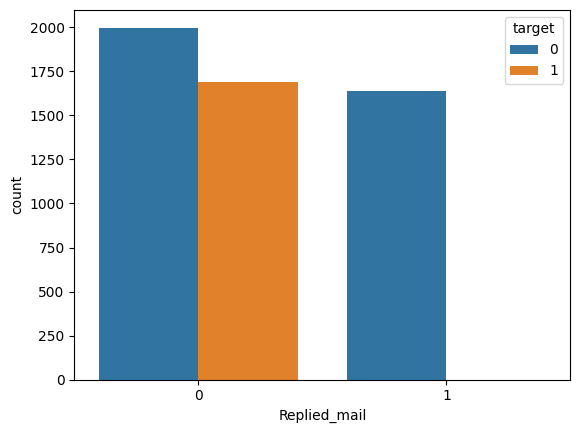

In [15]:
sns.countplot(x=spam_data['Replied_mail'], hue=spam_data['target'])
plt.show()

<h4><font face=verdona><b> Observation : </b><br>The graph above validates my knowledge, as none of the replied emails are marked as spam.

In [16]:
spam_data.drop(columns=['In-Reply-To:'], inplace=True)
spam_data

,text,target,From:,To:,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,List-Unsubscribe:,List-Subscribe:,wrote:,Replied_mail
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,Conor Daly <conor.daly@oceanfree.net>,ILUG main list <ilug@linux.ie>,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,None,1
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"""irese"" <gort44@excite.com>",<chrbader@telecom.at>,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,None,None,None,0
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1,<5447q67@bolehmail.com>,"<fork-request@xent.com>, <fork@spamassassin.ta...","Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...","<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",None,0
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1,"""Rudy Chan""<dcm123@btamail.net.cn>",shandatch@netnoir.net,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,None,None,None,0
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0,Philip Reynolds <phil@redbrick.dcu.ie>,ilug@linux.ie,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0,"""Paul O'Neil"" <poneil@dbiassociates.net>",<ilug@linux.ie>,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,0
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0,CDale <cdale@techmonkeys.net>,bitbitch@magnesium.net,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,"<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",> > > So I get a check from Pac Bell today (SB...,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,1,Ebargains <ebargains@reply.mb00.net>,cypherpunks@einstein.ssz.com,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,0
5327,From razor-users-admin@lists.sourceforge.net T...,0,David Raistrick <drais@wow.atlasta.net>,"""Rose, Bobby"" <brose@med.wayne.edu>","Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,<https://example.sourceforge.net/lists/listinf...,<https://example.sourceforge.net/lists/listinf...,> Use the sample-spam.txt from Spamassassin an...,1


<h4><font color=yellow face=verdona><hr>Analyzing "To:" feature<hr></font>
<h4><font face=verdona> We know that if the number of recipients is large, there is a high likelihood that the email is spam, as spam emails are typically sent in bulk.

In [17]:
spam_data['Recievers_count'] = spam_data['To:'].apply(lambda x: len(str(x).split('@')) - 1)
spam_data

,text,target,From:,To:,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,List-Unsubscribe:,List-Subscribe:,wrote:,Replied_mail,Recievers_count
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,Conor Daly <conor.daly@oceanfree.net>,ILUG main list <ilug@linux.ie>,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,None,1,1
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"""irese"" <gort44@excite.com>",<chrbader@telecom.at>,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,None,None,None,0,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1,<5447q67@bolehmail.com>,"<fork-request@xent.com>, <fork@spamassassin.ta...","Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...","<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",None,0,2
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1,"""Rudy Chan""<dcm123@btamail.net.cn>",shandatch@netnoir.net,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,None,None,None,0,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0,Philip Reynolds <phil@redbrick.dcu.ie>,ilug@linux.ie,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,None,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0,"""Paul O'Neil"" <poneil@dbiassociates.net>",<ilug@linux.ie>,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,0,1
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0,CDale <cdale@techmonkeys.net>,bitbitch@magnesium.net,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,"<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",> > > So I get a check from Pac Bell today (SB...,1,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,1,Ebargains <ebargains@reply.mb00.net>,cypherpunks@einstein.ssz.com,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,0,1
5327,From razor-users-admin@lists.sourceforge.net T...,0,David Raistrick <drais@wow.atlasta.net>,"""Rose, Bobby"" <brose@med.wayne.edu>","Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,<https://example.sourceforge.net/lists/listinf...,<https://example.sourceforge.net/lists/listinf...,> Use the sample-spam.txt from Spamassassin an...,1,1


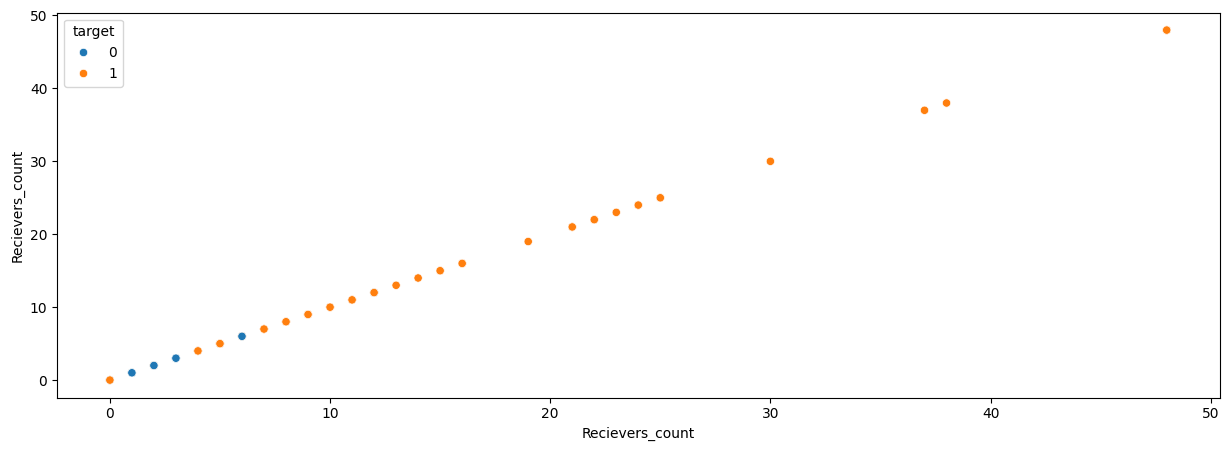

In [18]:
plt.figure(figsize=(15,5))
sns.scatterplot(x=spam_data['Recievers_count'],y=spam_data['Recievers_count'], hue=spam_data['target'])
plt.show()

<h4><font face=verdona><b> Observation : </b><br>Again the graph above validates my knowledge, as emails with higher recievers count are marked as spam.

In [19]:
len(spam_data['From:'].unique())

2512

In [20]:
spam_data['From:'].value_counts()

From:
boingboing <rssfeeds@spamassassin.taint.org>       104
guardian <rssfeeds@spamassassin.taint.org>          85
Tom <tomwhore@slack.net>                            81
Gary Lawrence Murphy <garym@canada.com>             76
newscientist <rssfeeds@spamassassin.taint.org>      75
                                                  ... 
Frank Burkhardt <burk@cns.mpg.de>                    1
"Tammie" <qxeye@home.se>                             1
<michael@i-magery.com>                               1
traci17fbi@yahoo.com                                 1
"Homes-4-Sale" <aweber@foreclosureworld.net>         1
Name: count, Length: 2512, dtype: int64

In [21]:
# The from column seems to have repeating email ids, but if provided  the model will perform well only on this data and not on general dataset
# or any random emails, this feature would play important only for this dataset and not any data.
spam_data.drop(columns=['From:','To:'], inplace=True)
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,List-Unsubscribe:,List-Subscribe:,wrote:,Replied_mail,Recievers_count
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,None,1,1
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,None,None,None,0,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...","<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",None,0,2
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,None,None,None,0,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,None,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,0,1
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,"<http://xent.com/mailman/listinfo/fork>, <mail...","<http://xent.com/mailman/listinfo/fork>, <mail...",> > > So I get a check from Pac Bell today (SB...,1,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,1,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,0,1
5327,From razor-users-admin@lists.sourceforge.net T...,0,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,<https://example.sourceforge.net/lists/listinf...,<https://example.sourceforge.net/lists/listinf...,> Use the sample-spam.txt from Spamassassin an...,1,1


<h4><font color=yellow face=verdona><hr>Analyzing "List-Subscribe:,List-Unsubscribe:" feature<hr></font>
<h4><font face=verdona> "list-subscribe" indicates the recipient has enrolled for email communications, while "list-unsubscribe" provides a mechanism for them to opt-out and stop receiving emails from that specific mailing list or organization - Google<br>Therefore, emails containing a subscribe link suggest that the recipient willingly signed up to receive them, making them less likely to be spam. The same applies to emails with an unsubscribe option, as legitimate senders typically include it to comply with email regulations.

In [22]:
spam_data['target'] = spam_data['target'].map({0: 'not_spam', 1: 'spam'})

In [23]:
spam_data['List-Subscribe:'] = np.where(pd.isna(spam_data['List-Subscribe:']), "Not_subscribed", "Subscribed")
spam_data['List-Unsubscribe:'] = np.where(pd.isna(spam_data['List-Unsubscribe:']), "No_unsub_option", "unsub_option")
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,List-Unsubscribe:,List-Subscribe:,wrote:,Replied_mail,Recievers_count
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,No_unsub_option,Not_subscribed,None,1,1
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,No_unsub_option,Not_subscribed,None,0,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...",unsub_option,Subscribed,None,0,2
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,No_unsub_option,Not_subscribed,None,0,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,No_unsub_option,Not_subscribed,None,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,No_unsub_option,Not_subscribed,None,0,1
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,unsub_option,Subscribed,> > > So I get a check from Pac Bell today (SB...,1,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,No_unsub_option,Not_subscribed,None,0,1
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,unsub_option,Subscribed,> Use the sample-spam.txt from Spamassassin an...,1,1


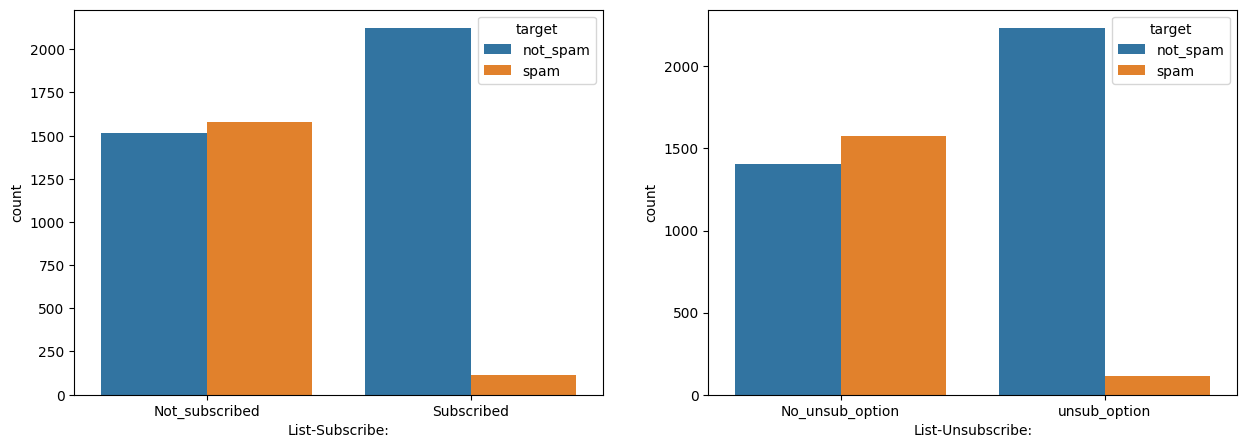

In [24]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(x=spam_data['List-Subscribe:'], hue=spam_data['target'], ax=ax[0])
sns.countplot(x=spam_data['List-Unsubscribe:'], hue=spam_data['target'], ax=ax[1])
plt.show()

<h4><font face=verdona><b> Observation : </b><br>The graph above validates my knowledge, as emails with Subscription,Unsubscribe option present are mostly marked as not spam.

In [25]:
spam_data['Sub_Unsub_link'] = np.where(
    (spam_data['List-Subscribe:'] == 'Subscribed') | (spam_data['List-Unsubscribe:'] == 'unsub_option'), 1, 0)
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,List-Unsubscribe:,List-Subscribe:,wrote:,Replied_mail,Recievers_count,Sub_Unsub_link
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,No_unsub_option,Not_subscribed,None,1,1,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,No_unsub_option,Not_subscribed,None,0,1,0
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...",unsub_option,Subscribed,None,0,2,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,No_unsub_option,Not_subscribed,None,0,1,0
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,No_unsub_option,Not_subscribed,None,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,No_unsub_option,Not_subscribed,None,0,1,0
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,unsub_option,Subscribed,> > > So I get a check from Pac Bell today (SB...,1,1,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,No_unsub_option,Not_subscribed,None,0,1,0
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,unsub_option,Subscribed,> Use the sample-spam.txt from Spamassassin an...,1,1,1


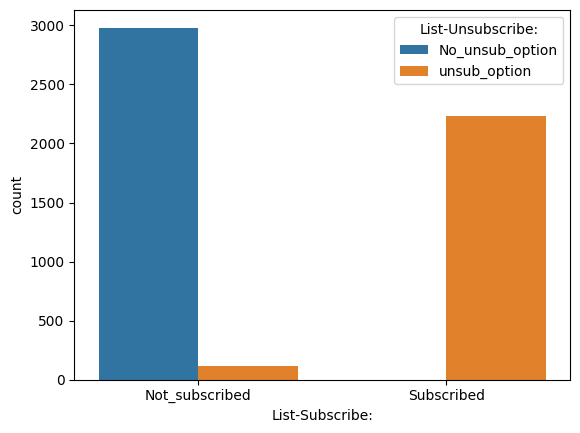

In [26]:
sns.countplot(x=spam_data['List-Subscribe:'], hue=spam_data['List-Unsubscribe:'])
plt.show()

<h4><font face=verdona>We know the emails that have subscription will only have the unsubsription option, as also can be seen in the above graph.

In [27]:
spam_data.drop(columns=['List-Subscribe:','List-Unsubscribe:'], inplace=True)
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,wrote:,Replied_mail,Recievers_count,Sub_Unsub_link
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,1,1,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,None,0,1,0
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...",None,0,2,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,None,0,1,0
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,0,1,0
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,> > > So I get a check from Pac Bell today (SB...,1,1,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,0,1,0
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,> Use the sample-spam.txt from Spamassassin an...,1,1,1


<h4><font color=yellow face=verdona><hr>Analyzing "Precedence:, wrote:, Content-Transfer-Encoding:" feature<hr></font

In [28]:
spam_data['Precedence:'].value_counts()

Precedence:
bulk                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

<h4><font face=verdona>We can see the most number of records are either null or "bulk",  but there are  few records, that contain any content so we need to parse the content and extract it

In [29]:
def add_prec_content(row):
    try : 
        return  row[5:].strip()
    except TypeError : 
        return ""
    
spam_data['Prec_content'] = spam_data['Precedence:'].apply(add_prec_content)
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,wrote:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,1,1,0,
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,None,0,1,0,
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...",None,0,2,1,
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,7bit <HTML><HEAD><TITLE>Free Card Search</TITL...,None,0,1,0,
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,1,1,0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,0,1,0,
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,None,> > > So I get a check from Pac Bell today (SB...,1,1,1,
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,0,1,0,
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,None,> Use the sample-spam.txt from Spamassassin an...,1,1,1,


In [30]:
spam_data['Prec_content'].value_counts()

Prec_content
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

<h3><font color=yellow face=verdona>Parsing Text from columns containing unparsed text

In [31]:
def parse_text(data, col):
        for index, text in enumerate(data[col]):
                try : 
                        soup = BeautifulSoup(data[col][index], 'lxml')
                        parsed_text = soup.text.strip()
                except Exception as ex :
                        parsed_text = ""
                finally :
                        data.loc[index, col] = parsed_text
        return data

spam_data = parse_text(spam_data, 'Content-Transfer-Encoding:')
spam_data = parse_text(spam_data, 'Prec_content')
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Precedence:,Content-Transfer-Encoding:,wrote:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,,None,1,1,0,
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",None,7bit Mortgage Lenders & Brokers Are Ready to c...,None,0,1,0,
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit Dear Homeowner, Interest Rates are at the...",None,0,2,1,
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit Free Card Search Sincerely,Your New...",None,0,1,0,
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,bulk,,None,1,1,0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,0,1,0,
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,bulk,,> > > So I get a check from Pac Bell today (SB...,1,1,1,
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,,None,0,1,0,
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,bulk,,> Use the sample-spam.txt from Spamassassin an...,1,1,1,


In [32]:
spam_data.isna().sum()

text                             0
target                           0
Date:                            0
Subject:                         5
Received:                      133
Content-Type:                  740
Precedence:                   2226
Content-Transfer-Encoding:       0
wrote:                        4215
Replied_mail                     0
Recievers_count                  0
Sub_Unsub_link                   0
Prec_content                     0
dtype: int64

In [33]:
spam_data.drop(columns=['Precedence:'], inplace=True)

<h4><font color=yellow face=verdona><hr>Analyzing "wrote:" feature<hr></font>


In [34]:
for row in  spam_data['wrote:']:
    try : 
        if '<' in row :
            print(row)
    except Exception as ex:
        pass

> > > > > The server mentioned above works again now :)! > > > > Any problems with the rpm's they provided? > > > > > > _______________________________________________ > > RPM-List mailing list <RPM-List@freshrpms.net> > > http://lists.freshrpms.net/mailman/listinfo/rpm-list > > #redhat 7.3 > rpm http://apt.sunnmore.net gnome2 73 > rpm-src http://apt.sunnmore.net gnome2 73 > > #redhat 7.2 > rpm http://apt.sunnmore.net gnome2 72 > rpm-src http://apt.sunnmore.net gnome2 72 > > thats the correct lines to be added to sources.list for the repository > > i just did a apt-get install gnome-session its still progressing :) > after apt-get install gnome-session i did another apt-get upgrade (25 more packages) and it works now... i am in gnome 2.0 wohooooo :) looks very great very "tidy" only error message i got was about a mixer applet on login (no biggie to me) even the old sawfish still works. yet its great and works cant say anythign negative yet :) just btw. if someone knows any other nice 

In [35]:
spam_data = parse_text(spam_data, 'wrote:')
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Content-Transfer-Encoding:,wrote:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,,,1,1,0,
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",7bit Mortgage Lenders & Brokers Are Ready to c...,,0,1,0,
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""","8bit Dear Homeowner, Interest Rates are at the...",,0,2,1,
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,"7bit Free Card Search Sincerely,Your New...",,0,1,0,
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,,,1,1,0,
...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",7bit,,0,1,0,
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,,> > > So I get a check from Pac Bell today (SB...,1,1,1,
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",,,0,1,0,
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,,> Use the sample-spam.txt from Spamassassin an...,1,1,1,


In [36]:
def clean_text(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)
spam_data['Wrote_content'] = spam_data['wrote:'].apply(clean_text)
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Content-Transfer-Encoding:,wrote:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content,Wrote_content
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,,,1,1,0,,
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",7bit Mortgage Lenders & Brokers Are Ready to c...,,0,1,0,,
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""","8bit Dear Homeowner, Interest Rates are at the...",,0,2,1,,
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,"7bit Free Card Search Sincerely,Your New...",,0,1,0,,
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,,,1,1,0,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",7bit,,0,1,0,,
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,,> > > So I get a check from Pac Bell today (SB...,1,1,1,,So I get a check from Pac Bell today SBC as...
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",,,0,1,0,,
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,,> Use the sample-spam.txt from Spamassassin an...,1,1,1,,Use the samplespamtxt from Spamassassin and d...


In [37]:
spam_data['Wrote_content'].value_counts()

Wrote_content
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [38]:
spam_data.drop(columns=['wrote:'], inplace=True)
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Content-Transfer-Encoding:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content,Wrote_content
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,,1,1,0,,
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""Windows-1252""",7bit Mortgage Lenders & Brokers Are Ready to c...,0,1,0,,
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""","8bit Dear Homeowner, Interest Rates are at the...",0,2,1,,
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,"7bit Free Card Search Sincerely,Your New...",0,1,0,,
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",text/plain; charset=us-ascii,,1,1,0,,
...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",7bit,0,1,0,,
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,TEXT/PLAIN; charset=US-ASCII,,1,1,1,,So I get a check from Pac Bell today SBC as...
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",,0,1,0,,
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,TEXT/PLAIN; charset=US-ASCII,,1,1,1,,Use the samplespamtxt from Spamassassin and d...


<h4><font color=yellow face=verdona><hr>Analyzing "Content-Type:" feature<hr>

In [39]:
spam_data['Content-Type:'] = spam_data['Content-Type:'].apply(lambda x : str(x).lower())
spam_data['Content-Type:']

0             text/plain; charset=us-ascii 
1       text/plain; charset="windows-1252" 
2           text/plain; charset="us-ascii" 
3              text/html; charset=us-ascii 
4             text/plain; charset=us-ascii 
                       ...                 
5324      text/plain; charset="iso-8859-1" 
5325          text/plain; charset=us-ascii 
5326       text/html; charset="iso-8859-1" 
5327          text/plain; charset=us-ascii 
5328            text/plain; encoding=utf-8 
Name: Content-Type:, Length: 5329, dtype: object

In [40]:
spam_data['Content-Type:'].value_counts()

Content-Type:
text/plain; charset=us-ascii                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [41]:
spam_data['Content-Type:'] = spam_data['Content-Type:'].apply(lambda x: x[5:].split(';')[0].strip() if ';' in str(x) else x)
spam_data['Content-Type:']

0       plain
1       plain
2       plain
3        html
4       plain
        ...  
5324    plain
5325    plain
5326     html
5327    plain
5328    plain
Name: Content-Type:, Length: 5329, dtype: object

In [42]:
for val, cnt in spam_data['Content-Type:'].value_counts().items():
    if 'plain' in val:
        print(val,cnt)

plain 3350
text/plain  172
text/plain charset=us-ascii  1


In [43]:
spam_data['Content-Type:'] = spam_data['Content-Type:'].apply(lambda x: 'html' if 'html' in str(x) else ('none' if 'none' in str(x) else 'plain'))
spam_data['Content-Type:'].value_counts()

Content-Type:
plain    3660
html      929
none      740
Name: count, dtype: int64

In [44]:
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Content-Transfer-Encoding:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content,Wrote_content
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,plain,,1,1,0,,
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,plain,7bit Mortgage Lenders & Brokers Are Ready to c...,0,1,0,,
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,plain,"8bit Dear Homeowner, Interest Rates are at the...",0,2,1,,
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,html,"7bit Free Card Search Sincerely,Your New...",0,1,0,,
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",plain,,1,1,0,,
...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,plain,7bit,0,1,0,,
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,plain,,1,1,1,,So I get a check from Pac Bell today SBC as...
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,html,,0,1,0,,
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,plain,,1,1,1,,Use the samplespamtxt from Spamassassin and d...


<h4><font face=verdona>We know formal/ non advertising emails contain plain text whereas adverstising or spam emails contain html type text

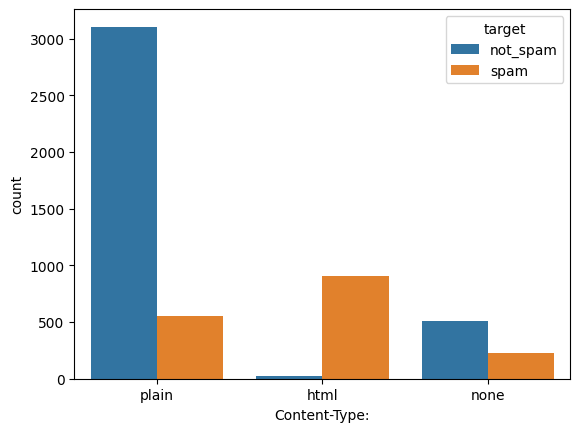

In [45]:
sns.countplot(x=spam_data['Content-Type:'], hue=spam_data['target'])
plt.show()

<h4><font face=verdona><b> Observation : </b><br>The graph above validates my knowledge, thus we will use one hot encoding to use this feature in our dataframe. Each category is associated with a class of the independent variable.

In [46]:
print(spam_data['Content-Type:'].unique())

['plain' 'html' 'none']


<h3><font face=verdona>Cardinal Encoding using OneHotEncoder

In [47]:
ohe = OneHotEncoder(sparse_output=False) 
encoded_content_type = ohe.fit_transform(spam_data[['Content-Type:']]) 
encoded_df = pd.DataFrame(encoded_content_type, columns=ohe.get_feature_names_out(['Content-Type:']))
encoded_df.head()

,Content-Type:_html,Content-Type:_none,Content-Type:_plain
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [48]:
spam_data['Content_type_html'] = encoded_df['Content-Type:_html'].astype(int)
spam_data['Content_type_plain'] = encoded_df['Content-Type:_plain'].astype(int)
spam_data

,text,target,Date:,Subject:,Received:,Content-Type:,Content-Transfer-Encoding:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content,Wrote_content,Content_type_html,Content_type_plain
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,plain,,1,1,0,,,0,1
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,plain,7bit Mortgage Lenders & Brokers Are Ready to c...,0,1,0,,,0,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,plain,"8bit Dear Homeowner, Interest Rates are at the...",0,2,1,,,0,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,html,"7bit Free Card Search Sincerely,Your New...",0,1,0,,,1,0
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",plain,,1,1,0,,,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,plain,7bit,0,1,0,,,0,1
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,plain,,1,1,1,,So I get a check from Pac Bell today SBC as...,0,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,html,,0,1,0,,,1,0
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,plain,,1,1,1,,Use the samplespamtxt from Spamassassin and d...,0,1


In [49]:
spam_data.drop(columns=['Content-Type:'], inplace=True)

<h4><font color=yellow face=verdona><hr>Analyzing "Date:, Recieved:" feature<hr>

In [50]:
spam_data

,text,target,Date:,Subject:,Received:,Content-Transfer-Encoding:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content,Wrote_content,Content_type_html,Content_type_plain
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,"Sat, 27 Jul 2002 14:27:49 +0100",,(from cdaly@localhost) by Hobbiton.cod.ie (8.1...,,1,1,0,,,0,1
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,"Tue, 04 Jun 2002 00:18:34 -1600",Cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,7bit Mortgage Lenders & Brokers Are Ready to c...,0,1,0,,,0,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,"Fri, 26 Jul 0102 18:03:12 +0900",Are Your Mortgage Rates The Best They Can Be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"8bit Dear Homeowner, Interest Rates are at the...",0,2,1,,,0,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,"Wed, 5 Jun 2002 21:17:22 -0700",Online Approval for $5000 Now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,"7bit Free Card Search Sincerely,Your New...",0,1,0,,,1,0
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,"Sat, 17 Aug 2002 22:07:11 +0100",,"by prodigy.redbrick.dcu.ie (Postfix, from user...",,1,1,0,,,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,"Mon, 22 Jul 2002 15:18:06 +0100",[ILUG] nmap results > I had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,7bit,0,1,0,,,0,1
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,"Mon, 7 Oct 2002 14:20:33 -0500 (CDT) It was a ...",,from localhost (sendmail-bs@127.0.0.1) by loca...,,1,1,1,,So I get a check from Pac Bell today SBC as...,0,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,"Sun, 21 Jul 2002 16:46:01 EDT",Real Drugs-Viagra and Phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,,0,1,0,,,1,0
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,"Thu, 12 Sep 2002 09:06:53 -0700 (PDT) On Tue, ...",Home Based Business for Grownups Sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,,1,1,1,,Use the samplespamtxt from Spamassassin and d...,0,1


<h4><font face=verdona>"Recieved from" emails ids and "date/time" of the emails may not a reliable feature to predict if the mail is spam or legit.

In [51]:
len(spam_data['Received:'].unique())

5161

In [52]:
len(spam_data['Date:'].unique())

5251

In [53]:
spam_data.drop(columns=['Received:','Date:'], inplace=True)
spam_data

,text,target,Subject:,Content-Transfer-Encoding:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content,Wrote_content,Content_type_html,Content_type_plain
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,,,1,1,0,,,0,1
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...,0,1,0,,,0,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the...",0,2,1,,,0,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New...",0,1,0,,,1,0
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,,,1,1,0,,,0,1
...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,[ILUG] nmap results > I had posted previously ...,7bit,0,1,0,,,0,1
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,,,1,1,1,,So I get a check from Pac Bell today SBC as...,0,1
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,Real Drugs-Viagra and Phentrimine!,,0,1,0,,,1,0
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,Home Based Business for Grownups Sep 12 12:04:...,,1,1,1,,Use the samplespamtxt from Spamassassin and d...,0,1


<h4><font color=yellow face=verdona><hr>Analyzing "Subject:" feature<hr>

In [54]:
spam_data = parse_text(spam_data, 'Subject:')
spam_data['Subject:'].value_counts()

Subject:
                                                   2131
[Spambayes] test sets?                               28
[Spambayes] Deployment                               26
[Razor-users]                                        23
[SACVS]                                              22
                                                   ... 
A Guaranteed Check for you                            1
Be First...It"s Your Turn...Don't Miss Out! nox       1
FREE Cell Phone + $50 Cash Back!                      1
New Strongbad E-Mail                                  1
[ILUG] FREE FREE FREE!                                1
Name: count, Length: 2750, dtype: int64

In [55]:
spam_data['Subject'] = spam_data['Subject:'].apply(lambda x: str(x).strip())
spam_data['Subject'] = spam_data['Subject'].apply(lambda x: "blank" if x == "" else x)
spam_data

,text,target,Subject:,Content-Transfer-Encoding:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content,Wrote_content,Content_type_html,Content_type_plain,Subject
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,,,1,1,0,,,0,1,blank
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...,0,1,0,,,0,1,Cash in on your home equity
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the...",0,2,1,,,0,1,Are Your Mortgage Rates The Best They Can Be.....
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New...",0,1,0,,,1,0,Online Approval for $5000 Now
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,,,1,1,0,,,0,1,blank
...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,[ILUG] nmap results > I had posted previously ...,7bit,0,1,0,,,0,1,[ILUG] nmap results > I had posted previously ...
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,,,1,1,1,,So I get a check from Pac Bell today SBC as...,0,1,blank
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,Real Drugs-Viagra and Phentrimine!,,0,1,0,,,1,0,Real Drugs-Viagra and Phentrimine!
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,Home Based Business for Grownups Sep 12 12:04:...,,1,1,1,,Use the samplespamtxt from Spamassassin and d...,0,1,Home Based Business for Grownups Sep 12 12:04:...


<h4><font face=verdona>Concatenating all the text content and into one feature

In [56]:
spam_data['Full_content'] = spam_data['Content-Transfer-Encoding:'].astype(str) +" "+ spam_data['Prec_content'].astype(str) +" "+ spam_data['Wrote_content'].astype(str)
spam_data

,text,target,Subject:,Content-Transfer-Encoding:,Replied_mail,Recievers_count,Sub_Unsub_link,Prec_content,Wrote_content,Content_type_html,Content_type_plain,Subject,Full_content
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,not_spam,,,1,1,0,,,0,1,blank,
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,spam,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...,0,1,0,,,0,1,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,spam,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the...",0,2,1,,,0,1,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the..."
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,spam,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New...",0,1,0,,,1,0,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New..."
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,not_spam,,,1,1,0,,,0,1,blank,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,not_spam,[ILUG] nmap results > I had posted previously ...,7bit,0,1,0,,,0,1,[ILUG] nmap results > I had posted previously ...,7bit
5325,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,not_spam,,,1,1,1,,So I get a check from Pac Bell today SBC as...,0,1,blank,So I get a check from Pac Bell today SBC ...
5326,Received: from hq.pro-ns.net (localhost [127.0...,spam,Real Drugs-Viagra and Phentrimine!,,0,1,0,,,1,0,Real Drugs-Viagra and Phentrimine!,
5327,From razor-users-admin@lists.sourceforge.net T...,not_spam,Home Based Business for Grownups Sep 12 12:04:...,,1,1,1,,Use the samplespamtxt from Spamassassin and d...,0,1,Home Based Business for Grownups Sep 12 12:04:...,Use the samplespamtxt from Spamassassin and...


In [57]:
spam_data.drop(columns=['Prec_content','Wrote_content','Content-Transfer-Encoding:', 'Subject:', 'text'], inplace=True)
spam_data

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content
0,not_spam,1,1,0,0,1,blank,
1,spam,0,1,0,0,1,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...
2,spam,0,2,1,0,1,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the..."
3,spam,0,1,0,1,0,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New..."
4,not_spam,1,1,0,0,1,blank,
...,...,...,...,...,...,...,...,...
5324,not_spam,0,1,0,0,1,[ILUG] nmap results > I had posted previously ...,7bit
5325,not_spam,1,1,1,0,1,blank,So I get a check from Pac Bell today SBC ...
5326,spam,0,1,0,1,0,Real Drugs-Viagra and Phentrimine!,
5327,not_spam,1,1,1,0,1,Home Based Business for Grownups Sep 12 12:04:...,Use the samplespamtxt from Spamassassin and...


In [58]:
spam_data['Full_content'] = spam_data['Full_content'].apply(lambda x: str(x).strip())
spam_data

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content
0,not_spam,1,1,0,0,1,blank,
1,spam,0,1,0,0,1,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...
2,spam,0,2,1,0,1,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the..."
3,spam,0,1,0,1,0,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New..."
4,not_spam,1,1,0,0,1,blank,
...,...,...,...,...,...,...,...,...
5324,not_spam,0,1,0,0,1,[ILUG] nmap results > I had posted previously ...,7bit
5325,not_spam,1,1,1,0,1,blank,So I get a check from Pac Bell today SBC as th...
5326,spam,0,1,0,1,0,Real Drugs-Viagra and Phentrimine!,
5327,not_spam,1,1,1,0,1,Home Based Business for Grownups Sep 12 12:04:...,Use the samplespamtxt from Spamassassin and do...


In [59]:
spam_data['Full_content'].value_counts()

Full_content
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [60]:
spam_data['Full_content'] = spam_data['Full_content'].apply(lambda x: "blank" if x == "" else x)
spam_data

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content
0,not_spam,1,1,0,0,1,blank,blank
1,spam,0,1,0,0,1,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...
2,spam,0,2,1,0,1,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the..."
3,spam,0,1,0,1,0,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New..."
4,not_spam,1,1,0,0,1,blank,blank
...,...,...,...,...,...,...,...,...
5324,not_spam,0,1,0,0,1,[ILUG] nmap results > I had posted previously ...,7bit
5325,not_spam,1,1,1,0,1,blank,So I get a check from Pac Bell today SBC as th...
5326,spam,0,1,0,1,0,Real Drugs-Viagra and Phentrimine!,blank
5327,not_spam,1,1,1,0,1,Home Based Business for Grownups Sep 12 12:04:...,Use the samplespamtxt from Spamassassin and do...


In [61]:
spam_data['Full_content'].value_counts()

Full_content
blank                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [62]:
no_contentdf = spam_data[(spam_data['Full_content']=="blank") & (spam_data['Subject']=="blank")]
no_contentdf

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content
0,not_spam,1,1,0,0,1,blank,blank
4,not_spam,1,1,0,0,1,blank,blank
33,not_spam,0,1,1,0,1,blank,blank
38,not_spam,0,0,0,0,0,blank,blank
47,not_spam,1,0,1,0,1,blank,blank
...,...,...,...,...,...,...,...,...
5266,not_spam,1,1,1,0,1,blank,blank
5276,not_spam,1,1,1,0,1,blank,blank
5285,not_spam,1,1,1,0,1,blank,blank
5307,not_spam,1,1,0,0,0,blank,blank


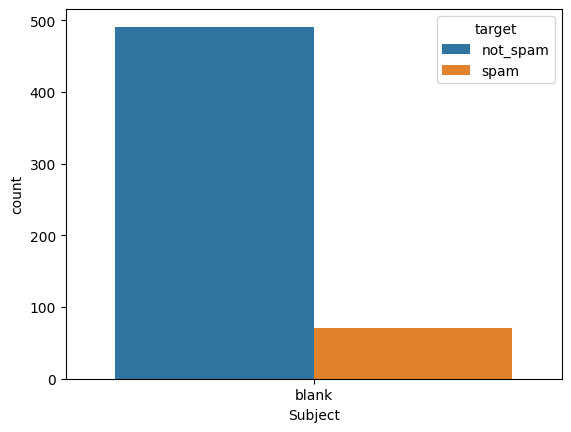

In [63]:
sns.countplot(x=no_contentdf['Subject'], hue=no_contentdf['target'])
plt.show()

<h4><font face=verdona>We know blank mails are mostly send with attachments and non formal mails , not spam mails and the graph supports our understanding, also since the other features play important role with respect to independent variable we cant remove these features.

<center><div style="background-color: brown"><h1><font color=white face="georgia">EDA

In [64]:
spam_data['target'] = spam_data['target'].map({ 'not_spam' : 0, 'spam' : 1})

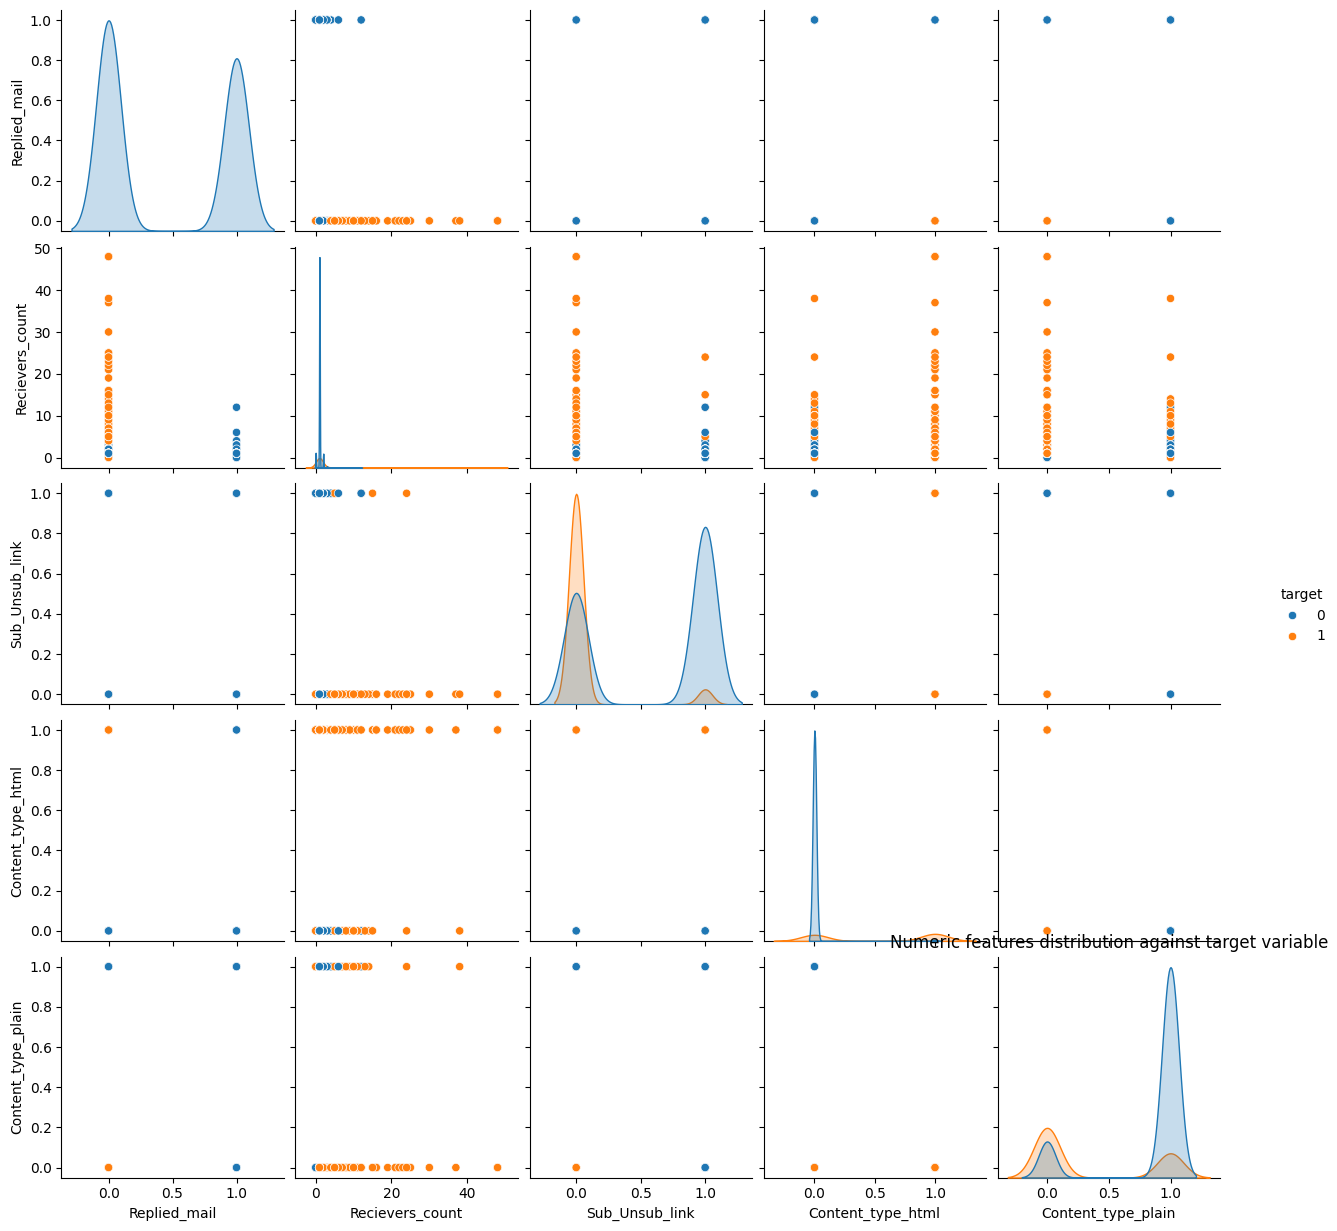

In [65]:
sns.pairplot(spam_data.select_dtypes(include=[int, float]), hue='target')
plt.title("Numeric features distribution against target variable")
plt.show()

<h4><font face=verdona><b>Observation:</b><br>We can see in binary  feature each category is associated with one class of the target variable.

<center><div style="background-color: brown"><h1><font color=white face="georgia">Feature Engineering

In [66]:
spam_data['content_char'] = spam_data['Full_content'].apply(len)
spam_data['sub_char'] = spam_data['Subject'].apply(len)
spam_data

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content,content_char,sub_char
0,0,1,1,0,0,1,blank,blank,5,5
1,1,0,1,0,0,1,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...,896,27
2,1,0,2,1,0,1,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the...",810,78
3,1,0,1,0,1,0,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New...",66,29
4,0,1,1,0,0,1,blank,blank,5,5
...,...,...,...,...,...,...,...,...,...,...
5324,0,0,1,0,0,1,[ILUG] nmap results > I had posted previously ...,7bit,4,417
5325,0,1,1,1,0,1,blank,So I get a check from Pac Bell today SBC as th...,866,5
5326,1,0,1,0,1,0,Real Drugs-Viagra and Phentrimine!,blank,5,34
5327,0,1,1,1,0,1,Home Based Business for Grownups Sep 12 12:04:...,Use the samplespamtxt from Spamassassin and do...,405,74


In [67]:
spam_data.describe()

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,content_char,sub_char
count,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000
mean,0.317320,0.307562,1.279602,0.440420,0.174329,0.686808,347.683993,47.245825
std,0.465477,0.461528,2.272757,0.496484,0.379428,0.463835,1240.979696,261.815935
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,5.000000,5.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.000000,17.000000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,305.000000,35.000000
max,1.000000,1.000000,48.000000,1.000000,1.000000,1.000000,37441.000000,7268.000000


<h4><font face=verdona>Scaling features using MinMaxScaler to scale within 0 to 1 range

In [68]:
from sklearn.preprocessing import MinMaxScaler
rec_cnt_scaler = MinMaxScaler((0,1))
recievers_cnt = rec_cnt_scaler.fit_transform(spam_data[['Recievers_count']])
spam_data['Recievers_count'] = recievers_cnt

In [69]:
sub_char_scaler = MinMaxScaler((0,1))
sub_char = sub_char_scaler.fit_transform(spam_data[['sub_char']])
spam_data['sub_char'] = sub_char

In [70]:
content_char_scaler = MinMaxScaler((0,1))
cont_char = content_char_scaler.fit_transform(spam_data[['content_char']])
spam_data['content_char'] = cont_char

In [71]:
spam_data

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content,content_char,sub_char
0,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
1,1,0,0.020833,0,0,1,Cash in on your home equity,7bit Mortgage Lenders & Brokers Are Ready to c...,0.023853,0.003578
2,1,0,0.041667,1,0,1,Are Your Mortgage Rates The Best They Can Be.....,"8bit Dear Homeowner, Interest Rates are at the...",0.021556,0.010596
3,1,0,0.020833,0,1,0,Online Approval for $5000 Now,"7bit Free Card Search Sincerely,Your New...",0.001683,0.003853
4,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
...,...,...,...,...,...,...,...,...,...,...
5324,0,0,0.020833,0,0,1,[ILUG] nmap results > I had posted previously ...,7bit,0.000027,0.057245
5325,0,1,0.020833,1,0,1,blank,So I get a check from Pac Bell today SBC as th...,0.023051,0.000550
5326,1,0,0.020833,0,1,0,Real Drugs-Viagra and Phentrimine!,blank,0.000053,0.004541
5327,0,1,0.020833,1,0,1,Home Based Business for Grownups Sep 12 12:04:...,Use the samplespamtxt from Spamassassin and do...,0.010738,0.010045


In [72]:
spam_data.describe()

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,content_char,sub_char
count,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000
mean,0.317320,0.307562,0.026658,0.440420,0.174329,0.686808,0.009207,0.006364
std,0.465477,0.461528,0.047349,0.496484,0.379428,0.463835,0.033148,0.036028
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.020833,0.000000,0.000000,0.000000,0.000053,0.000550
50%,0.000000,0.000000,0.020833,0.000000,0.000000,1.000000,0.000053,0.002202
75%,1.000000,1.000000,0.020833,1.000000,0.000000,1.000000,0.008067,0.004679
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


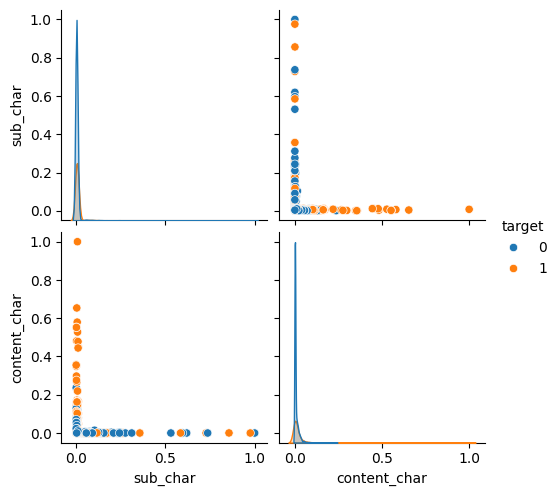

In [73]:
sns.pairplot(data=spam_data[['sub_char', 'content_char', 'target']], hue='target')
plt.show()

In [74]:
spam_data.isnull().sum()

target                0
Replied_mail          0
Recievers_count       0
Sub_Unsub_link        0
Content_type_html     0
Content_type_plain    0
Subject               0
Full_content          0
content_char          0
sub_char              0
dtype: int64

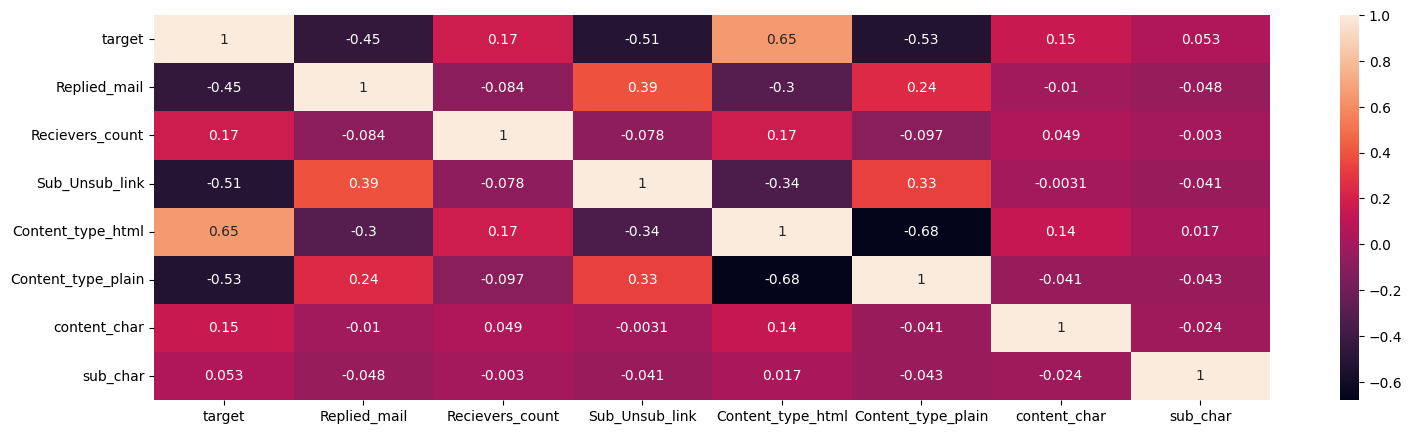

In [75]:
plt.figure(figsize=(18,5))
sns.heatmap(spam_data.corr(numeric_only=True), annot=True)
plt.show()

In [76]:
spam = spam_data[(spam_data['target'] == 1) & (spam_data['Subject'] != "blank")]
not_spam = spam_data[(spam_data['target']==0) & (spam_data['Subject'] != "blank")]

In [77]:
spam.describe()

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,content_char,sub_char
count,1519.0,1519.0,1519.000000,1519.000000,1519.000000,1519.000000,1519.000000,1519.000000
mean,1.0,0.0,0.036866,0.070441,0.544437,0.339039,0.016874,0.010124
std,0.0,0.0,0.080487,0.255973,0.498185,0.473539,0.055955,0.046450
min,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000027,0.000138
25%,1.0,0.0,0.020833,0.000000,0.000000,0.000000,0.000053,0.003303
50%,1.0,0.0,0.020833,0.000000,1.000000,0.000000,0.000347,0.004679
75%,1.0,0.0,0.020833,0.000000,1.000000,1.000000,0.015626,0.006192
max,1.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.975506


In [78]:
not_spam.describe()

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,content_char,sub_char
count,1679.0,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000
mean,0.0,0.167362,0.019878,0.423466,0.011316,0.784395,0.002728,0.010340
std,0.0,0.373410,0.008683,0.494255,0.105806,0.411364,0.012209,0.045805
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000027,0.000000
25%,0.0,0.000000,0.020833,0.000000,0.000000,1.000000,0.000053,0.002477
50%,0.0,0.000000,0.020833,0.000000,0.000000,1.000000,0.000053,0.003991
75%,0.0,0.000000,0.020833,1.000000,0.000000,1.000000,0.000053,0.005642
max,0.0,1.000000,0.125000,1.000000,1.000000,1.000000,0.133100,1.000000


<h3><font color=yellow face=verdona><hr>Building Wordcloud of Spam Records and Not Spam Records<hr>

In [79]:
from wordcloud import WordCloud

In [80]:
def generate_wc(data, title):
    all_text = ' '.join(data)
    wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(18, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(font='georgia',label=f'{title}')
    plt.axis('off')
    plt.show()

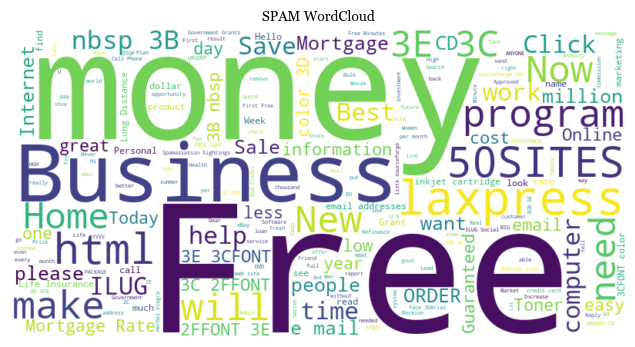

In [81]:
generate_wc(spam['Subject'],'SPAM WordCloud')

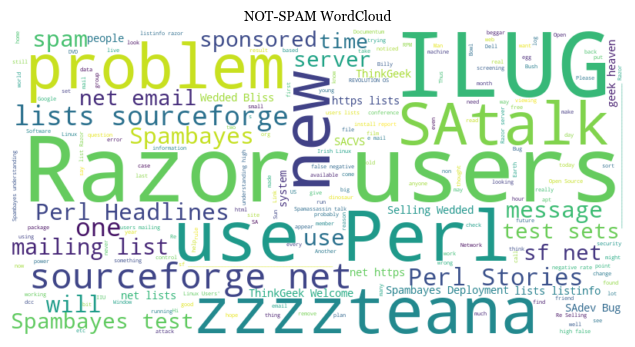

In [82]:
generate_wc(not_spam['Subject'],'NOT-SPAM WordCloud')

<center><div style="background-color: brown"><h1><font color=white face="georgia">Text Proprocessing

In [83]:
# Uncomment these while initial running 
# nltk.download('stopwords')
# nltk.download('wordnet')

<h3><font face=verdona>
Tokenization, Lowercasing, Removing punctuation, special characters and stop words, Stemming

In [84]:
spam_data['Subject'] = spam_data['Subject'].apply(lambda x: "blank" if x.strip() == "" else x)
spam_data['Full_content'] = spam_data['Full_content'].apply(lambda x: "blank" if x.strip() == "" else x)

In [85]:
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))

def preprocessing_text(text, stopwords=stop_words):
    text = re.sub('[^a-zA-Z]', ' ', text).lower()
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stopwords]
    return ' '.join(words)

In [86]:
preprocessed_df = spam_data.copy()
preprocessed_df['Subject'] = preprocessed_df['Subject'].apply(preprocessing_text)
preprocessed_df['Full_content'] = preprocessed_df['Full_content'].apply(preprocessing_text)
preprocessed_df

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content,content_char,sub_char
0,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
1,1,0,0.020833,0,0,1,cash home equiti,bit mortgag lender broker readi compet busi wh...,0.023853,0.003578
2,1,0,0.041667,1,0,1,mortgag rate best lkvt rfxd c,bit dear homeown interest rate lowest point ye...,0.021556,0.010596
3,1,0,0.020833,0,1,0,onlin approv,bit free card search sincer new offer staff remov,0.001683,0.003853
4,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
...,...,...,...,...,...,...,...,...,...,...
5324,0,0,0.020833,0,0,1,ilug nmap result post previous kernel use ipta...,bit,0.000027,0.057245
5325,0,1,0.020833,1,0,1,blank,get check pac bell today sbc theyr call turn w...,0.023051,0.000550
5326,1,0,0.020833,0,1,0,real drug viagra phentrimin,blank,0.000053,0.004541
5327,0,1,0.020833,1,0,1,home base busi grownup sep check,use samplespamtxt spamassassin razorcheck samp...,0.010738,0.010045


<h3><font face=verdona>
Tokenization, Lowercasing, Removing punctuation, special characters and stop words, Lemmatizing

In [87]:
lem = WordNetLemmatizer()
def preprocessing_text2(text, stopwords=stop_words):
    text = re.sub('[^a-zA-Z]', ' ', text).lower()
    words = text.split()
    words = [lem.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

In [88]:
preprocessed_df2 = spam_data.copy()
preprocessed_df2['Subject'] = preprocessed_df2['Subject'].apply(preprocessing_text2)
preprocessed_df2['Full_content'] = preprocessed_df2['Full_content'].apply(preprocessing_text2)
preprocessed_df2

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content,content_char,sub_char
0,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
1,1,0,0.020833,0,0,1,cash home equity,bit mortgage lender broker ready compete busin...,0.023853,0.003578
2,1,0,0.041667,1,0,1,mortgage rate best lkvt rfxd c,bit dear homeowner interest rate lowest point ...,0.021556,0.010596
3,1,0,0.020833,0,1,0,online approval,bit free card search sincerely new offer staff...,0.001683,0.003853
4,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
...,...,...,...,...,...,...,...,...,...,...
5324,0,0,0.020833,0,0,1,ilug nmap result posted previously kernel usin...,bit,0.000027,0.057245
5325,0,1,0.020833,1,0,1,blank,get check pac bell today sbc theyre called tur...,0.023051,0.000550
5326,1,0,0.020833,0,1,0,real drug viagra phentrimine,blank,0.000053,0.004541
5327,0,1,0.020833,1,0,1,home based business grownup sep check,use samplespamtxt spamassassin razorcheck samp...,0.010738,0.010045


In [89]:
preprocessed_df.to_csv('datasets/preprocessed_df.csv')
preprocessed_df = pd.read_csv('datasets/preprocessed_df.csv',index_col=0)
preprocessed_df

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content,content_char,sub_char
0,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
1,1,0,0.020833,0,0,1,cash home equiti,bit mortgag lender broker readi compet busi wh...,0.023853,0.003578
2,1,0,0.041667,1,0,1,mortgag rate best lkvt rfxd c,bit dear homeown interest rate lowest point ye...,0.021556,0.010596
3,1,0,0.020833,0,1,0,onlin approv,bit free card search sincer new offer staff remov,0.001683,0.003853
4,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
...,...,...,...,...,...,...,...,...,...,...
5324,0,0,0.020833,0,0,1,ilug nmap result post previous kernel use ipta...,bit,0.000027,0.057245
5325,0,1,0.020833,1,0,1,blank,get check pac bell today sbc theyr call turn w...,0.023051,0.000550
5326,1,0,0.020833,0,1,0,real drug viagra phentrimin,blank,0.000053,0.004541
5327,0,1,0.020833,1,0,1,home base busi grownup sep check,use samplespamtxt spamassassin razorcheck samp...,0.010738,0.010045


In [90]:
preprocessed_df2.to_csv('datasets/preprocessed_df2.csv')
preprocessed_df2 = pd.read_csv('datasets/preprocessed_df2.csv',index_col=0)
preprocessed_df2

,target,Replied_mail,Recievers_count,Sub_Unsub_link,Content_type_html,Content_type_plain,Subject,Full_content,content_char,sub_char
0,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
1,1,0,0.020833,0,0,1,cash home equity,bit mortgage lender broker ready compete busin...,0.023853,0.003578
2,1,0,0.041667,1,0,1,mortgage rate best lkvt rfxd c,bit dear homeowner interest rate lowest point ...,0.021556,0.010596
3,1,0,0.020833,0,1,0,online approval,bit free card search sincerely new offer staff...,0.001683,0.003853
4,0,1,0.020833,0,0,1,blank,blank,0.000053,0.000550
...,...,...,...,...,...,...,...,...,...,...
5324,0,0,0.020833,0,0,1,ilug nmap result posted previously kernel usin...,bit,0.000027,0.057245
5325,0,1,0.020833,1,0,1,blank,get check pac bell today sbc theyre called tur...,0.023051,0.000550
5326,1,0,0.020833,0,1,0,real drug viagra phentrimine,blank,0.000053,0.004541
5327,0,1,0.020833,1,0,1,home based business grownup sep check,use samplespamtxt spamassassin razorcheck samp...,0.010738,0.010045


In [91]:
preprocessed_df.fillna("blank", inplace=True)
preprocessed_df2.fillna("blank", inplace=True)

<h3><font color=blue face=verdona><center>Plotting the 30 most frequent words used in Spam and not spam Emails

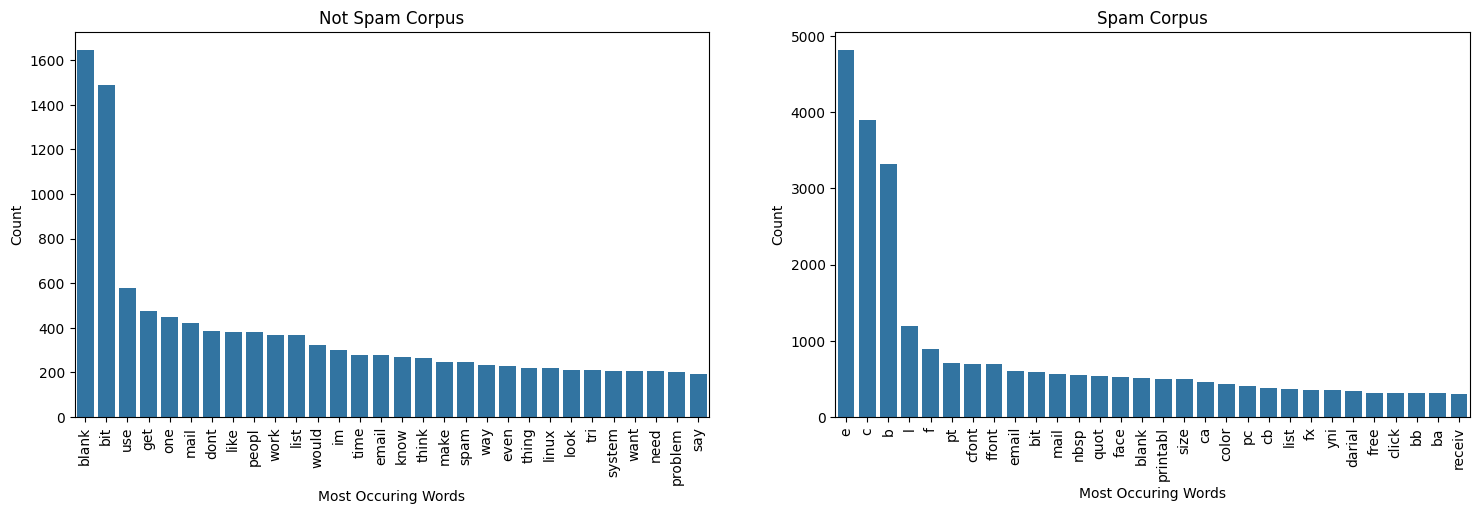

In [92]:
import warnings 
warnings.filterwarnings('ignore')

spam_corpus = []
not_spam_corpus = []
for index, text in enumerate(preprocessed_df['Full_content']):
    if preprocessed_df['target'][index] == 0:
        not_spam_corpus.extend(text.split())
    else:
        spam_corpus.extend(text.split())

from collections import Counter
corpuses = [not_spam_corpus, spam_corpus]
corpus_names = ['Not Spam Corpus', 'Spam Corpus']
fig , ax = plt.subplots(nrows=1, ncols=2, figsize=(18,5))
axes = ax.flatten()
for i in range(2):
    sns.barplot(x=pd.DataFrame(Counter(corpuses[i]).most_common(30))[0], 
                y=pd.DataFrame(Counter(corpuses[i]).most_common(30))[1], ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation='vertical')
    axes[i].set_xlabel('Most Occuring Words')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{corpus_names[i]}')
plt.show()

<h4><font face=verdona> The corpuses are not having a good understanding of the as the solid content of the data is unstructured though lot of useful information has still be extracted

<h3><font color=yellow face=verdona><center> Vectorization

In [93]:
# cv_content = CountVectorizer(max_features=3000)
# cv_subject = CountVectorizer(max_features=3000)
tfidf_content = TfidfVectorizer(max_features=3000)
tfidf_subject = TfidfVectorizer(max_features=3000)

In [94]:
# content_vectors = cv_content.fit_transform(preprocessed_df['Full_content']).toarray()
# subject_vectors = cv_subject.fit_transform(preprocessed_df['Subject']).toarray()
content_vectors = tfidf_content.fit_transform(preprocessed_df['Full_content']).toarray()
subject_vectors = tfidf_subject.fit_transform(preprocessed_df['Subject']).toarray()

In [95]:
print(content_vectors.shape, subject_vectors.shape)

(5329, 3000) (5329, 3000)


In [96]:
vec_array = np.concatenate((content_vectors, subject_vectors), axis=1)
vec_array

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [97]:
print(vec_array.shape)

(5329, 6000)


In [98]:
X = vec_array
X.shape

(5329, 6000)

In [99]:
y = preprocessed_df['target'].values
y.shape

(5329,)

In [100]:
X_trimmed = X[:-10, :]
y_trimmed = y[:-10]

<center><div style="background-color: brown"><h1><font color=white face="georgia">Train Test Split<br>
    Various Models Training and Evaluation

<h3><font face=verdona> Training models only on<font color=yellow> text</font> features

Some models were commented out because of their high time complexity

In [101]:
# pca = PCA(n_components=10)

# These models are commented out considering Time complexity
# gb = GradientBoostingClassifier()
# rforest = RandomForestClassifier(class_weight='balanced') 
# svc = SVC(kernel='linear')
# xgb = XGBClassifier(scale_pos_weight=3)
# xgbrf = XGBRFClassifier(scale_pos_weight=5)

dtree = DecisionTreeClassifier(class_weight='balanced',min_samples_leaf=15)
lgb_model = LGBMClassifier(class_weight='balanced', verbose=-1)
knc = KNeighborsClassifier(weights='uniform')
l_reg = LogisticRegression(class_weight='balanced')
gnb = GaussianNB()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = [dtree, lgb_model, knc, l_reg, gnb ] #,rforest, xgb, xgbrf, svc, gb]
model_names = ['DTree', 'LightGBM', 'KNNeighbors','Logistic Regression', 'GNB']
            #    , 'RForest', 'XGBoost', 'XGBRF', 'SVC', 'Gradient Boosting']

best_models = {}
models_mean_scores = {}

for i, model in enumerate(models):
    model_name = model_names[i]
    best_recall = 0.0

    print(f'\n\t\t\t\t{model_name}')
    results = []

    for train_indices, test_indices in kfold.split(X_trimmed):     
        start = time.time()       
        X_train, X_test, y_train, y_test = X_trimmed[train_indices], X_trimmed[test_indices], y_trimmed[train_indices], y_trimmed[test_indices]
        # X_train = pca.fit_transform(X_train)

        model.fit(X_train, y_train)

        # X_test = pca.transform(X_test)
        y_pred_cm = model.predict(X_test)#[:, 1]

        # y_pred_cm = np.where(y_pred > 0.5, 1, 0)
        acc_scr = accuracy_score(y_test, y_pred_cm)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cm).ravel()
        specificity = round(tn / (tn + fp), 2)

        recall = recall_score(y_test, y_pred_cm)
        time_elapsed = time.time() - start

        results.append({
            'Specificity (TNR)' : specificity, # True Negative Rate 
            'Recall (TPR)' : round(recall, 3),
            'Accuracy': round(acc_scr, 3),
            'Time Taken (s)': round(time_elapsed, 2)
        })

        if recall > best_recall:
            best_accuracy = recall
            best_models[model_name] = {
                'Model': model
            }

    models_mean_scores[model_name] = {
        'Recall (TPR)' : np.mean([r['Recall (TPR)'] for r in results]),
        'Specificity (TNR)' : np.mean([r['Specificity (TNR)'] for r in results]),
        }

    results_df = pd.DataFrame(results)

    print(results_df.to_string(index=False))
    print("-" * 80)
    print(f'Mean:\t     {round(results_df['Specificity (TNR)'].mean(),
                                3)}\t   {round(results_df['Recall (TPR)'].mean(), 
                                3)}\t  {round(results_df["Accuracy"].mean(), 
                                3)}\t\t   {round(results_df['Time Taken (s)'].mean(), 2)}')


				DTree
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.88         0.734     0.834            5.00
              0.92         0.712     0.852            4.51
              0.90         0.734     0.846            4.30
              0.90         0.761     0.855            4.80
              0.87         0.773     0.839            5.01
--------------------------------------------------------------------------------
Mean:	     0.894	   0.743	  0.845		   4.72

				LightGBM
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.92         0.812     0.884            1.58
              0.94         0.806     0.895            1.81
              0.92         0.813     0.885            1.39
              0.92         0.805     0.883            1.51
              0.91         0.838     0.887            1.34
--------------------------------------------------------------------------------
Mean:	     0.922	   0.815	  0.887		   1.53

				KNNeighbors
 S

<h3><font face=verdona>Training models only on <font color=yellow> numeric</font> features

In [102]:
spam_data.columns

Index(['target', 'Replied_mail', 'Recievers_count', 'Sub_Unsub_link',
       'Content_type_html', 'Content_type_plain', 'Subject', 'Full_content',
       'content_char', 'sub_char'],
      dtype='object')

In [103]:
X_2 = spam_data[['content_char', 'sub_char', 'Replied_mail', 'Recievers_count',	'Sub_Unsub_link','Content_type_html','Content_type_plain']]
X_2 = X_2.to_numpy()
X_2.shape

(5329, 7)

In [104]:
X_2_trimmed = X_2[:-10, :]

In [105]:
# pca = PCA(n_components=10)

dtree = DecisionTreeClassifier(class_weight='balanced',min_samples_leaf=15)
lgb_model = LGBMClassifier(class_weight='balanced', verbose=-1)
knc = KNeighborsClassifier(weights='uniform')
l_reg = LogisticRegression(class_weight='balanced')
gnb = GaussianNB()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = [dtree, lgb_model, knc, l_reg, gnb ]
model_names = ['DTree', 'LightGBM', 'KNNeighbors','Logistic Regression', 'GNB']

best_models = {}
models_mean_scores = {}

for i, model in enumerate(models):
    model_name = model_names[i]
    best_recall = 0.0

    print(f'\n\t\t\t\t{model_name}')
    results = []

    for train_indices, test_indices in kfold.split(X_2_trimmed):            
        start = time.time()
        X_train, X_test, y_train, y_test = X_2_trimmed[train_indices], X_2_trimmed[test_indices], y_trimmed[train_indices], y_trimmed[test_indices]
        # X_train = pca.fit_transform(X_train)
        
        model.fit(X_train, y_train)

        # X_test = pca.transform(X_test)
        y_pred_cm = model.predict(X_test)#[:, 1]

        # y_pred_cm = np.where(y_pred > 0.5, 1, 0)
        acc_scr = accuracy_score(y_test, y_pred_cm)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cm).ravel()
        specificity = round(tn / (tn + fp), 2)

        recall = recall_score(y_test, y_pred_cm)
        time_elapsed = time.time() - start

        results.append({
            'Specificity (TNR)' : specificity, # True Negative Rate 
            'Recall (TPR)' : round(recall, 3),
            'Accuracy': round(acc_scr, 3),
            'Time Taken (s)': round(time_elapsed, 2)
        })

        if recall > best_recall:
            best_accuracy = recall
            best_models[model_name] = {
                'Model': model
            }

    models_mean_scores[model_name] = {
        'Recall (TPR)' : np.mean([r['Recall (TPR)'] for r in results]),
        'Specificity (TNR)' : np.mean([r['Specificity (TNR)'] for r in results]),
        }

    results_df = pd.DataFrame(results)

    print(results_df.to_string(index=False))
    print("-" * 80)
    print(f'Mean:\t     {round(results_df['Specificity (TNR)'].mean(),
                                3)}\t   {round(results_df['Recall (TPR)'].mean(), 
                                3)}\t  {round(results_df["Accuracy"].mean(), 
                                3)}\t\t   {round(results_df['Time Taken (s)'].mean(), 2)}')


				DTree
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.93         0.887     0.914            0.05
              0.93         0.915     0.928            0.00
              0.95         0.909     0.937            0.02
              0.94         0.881     0.924            0.02
              0.94         0.892     0.927            0.02
--------------------------------------------------------------------------------
Mean:	     0.938	   0.897	  0.926		   0.02

				LightGBM
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.96         0.881     0.937            0.20
              0.95         0.926     0.944            0.12
              0.96         0.906     0.945            0.14
              0.95         0.909     0.935            0.11
              0.97         0.872     0.936            0.09
--------------------------------------------------------------------------------
Mean:	     0.958	   0.899	  0.939		   0.13

				KNNeighbors
 S

<h3><font face=verdona>We have extracted very good numeric features from the texts which without even the text have good accuracy to if an email is spam or ham.

In [106]:
final_X = np.concatenate((X, X_2), axis=1)
print(final_X.shape)
final_X

(5329, 6007)


array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [107]:
y = preprocessed_df['target'].values
y.shape

(5329,)

In [108]:
final_X_trimmed = final_X[:-10, :]

In [109]:
# pca = PCA(n_components=10)

gb = GradientBoostingClassifier()
rforest = RandomForestClassifier(class_weight='balanced') 
svc = SVC(kernel='linear')
l_reg = LogisticRegression(class_weight='balanced')
xgb = XGBClassifier(scale_pos_weight=3)
xgbrf = XGBRFClassifier(scale_pos_weight=5)
dtree = DecisionTreeClassifier(class_weight='balanced',min_samples_leaf=15)
knc = KNeighborsClassifier(weights='uniform')
gnb = GaussianNB()
lgb_model = LGBMClassifier(class_weight='balanced', verbose=-1)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = [dtree, lgb_model, knc, l_reg, gnb ]
model_names = ['DTree', 'LightGBM', 'KNNeighbors','Logistic Regression', 'GNB']

best_models = {}
models_mean_scores = {}

for i, model in enumerate(models):
    model_name = model_names[i]
    best_recall = 0.0

    print(f'\n\t\t\t\t{model_name}')
    results = []

    for train_indices, test_indices in kfold.split(final_X_trimmed):            
        start = time.time()
        X_train, X_test, y_train, y_test = final_X_trimmed[train_indices], final_X_trimmed[test_indices], y_trimmed[train_indices], y_trimmed[test_indices]
        # X_train = pca.fit_transform(X_train)
        
        model.fit(X_train, y_train)

        # X_test = pca.transform(X_test)
        y_pred_cm = model.predict(X_test)#[:, 1]

        # y_pred_cm = np.where(y_pred > 0.5, 1, 0)
        acc_scr = accuracy_score(y_test, y_pred_cm)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cm).ravel()
        specificity = round(tn / (tn + fp), 2)

        recall = recall_score(y_test, y_pred_cm)
        time_elapsed = time.time() - start

        results.append({
            'Specificity (TNR)' : specificity, # True Negative Rate 
            'Recall (TPR)' : round(recall, 3),
            'Accuracy': round(acc_scr, 3),
            'Time Taken (s)': round(time_elapsed, 2)
        })

        if recall > best_recall:
            best_accuracy = recall
            best_models[model_name] = {
                # 'Scaler': scaler,
                'Model': model
            }

    models_mean_scores[model_name] = {
        'Recall (TPR)' : np.mean([r['Recall (TPR)'] for r in results]),
        'Specificity (TNR)' : np.mean([r['Specificity (TNR)'] for r in results]),
        }

    results_df = pd.DataFrame(results)

    print(results_df.to_string(index=False))
    print("-" * 80)
    print(f'Mean:\t     {round(results_df['Specificity (TNR)'].mean(),
                                3)}\t   {round(results_df['Recall (TPR)'].mean(), 
                                3)}\t  {round(results_df["Accuracy"].mean(), 
                                3)}\t\t   {round(results_df['Time Taken (s)'].mean(), 2)}')


				DTree
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.95         0.913     0.940            4.06
              0.94         0.923     0.934            4.29
              0.96         0.934     0.951            4.53
              0.96         0.896     0.938            4.42
              0.96         0.903     0.944            4.46
--------------------------------------------------------------------------------
Mean:	     0.954	   0.914	  0.941		   4.35

				LightGBM
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.97         0.910     0.954            1.51
              0.97         0.946     0.965            1.68
              0.98         0.946     0.969            1.52
              0.97         0.943     0.961            1.42
              0.98         0.932     0.961            1.36
--------------------------------------------------------------------------------
Mean:	     0.974	   0.935	  0.962		   1.5

				KNNeighbors
 Sp

<h3><font face=verdona color=yellow>The data is High dimensional data and Neural Networks (DL models) perform comparatively much better on such data.

In [120]:
ip_dim = final_X[-1:, :].shape[1]
import tensorflow as tf
def create_model():
    nn_model = tf.keras.models.Sequential([
        tf.keras.Input(shape=(ip_dim,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.6),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall()])
    return nn_model

In [121]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

results = []  
best_recall = 0.0
best_models = {}
model_name = 'ANN_clf' 

for train_indices, test_indices in kfold.split(final_X_trimmed):            
    start = time.time()
    model = create_model()
    X_train, X_test, y_train, y_test = final_X_trimmed[train_indices], final_X_trimmed[test_indices], y_trimmed[train_indices], y_trimmed[test_indices]
    
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

    
    loss, acc_scr, recall = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred = model.predict(X_test)
    y_pred_cm = np.where(y_pred > 0.5, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cm).ravel()
    specificity = tn / (tn + fp)

    time_elapsed = time.time() - start

    results.append({
        'Specificity (TNR)' : round(specificity,3), # True Negative Rate 
        'Recall (TPR)' : round(recall, 3),
        'Accuracy': round(acc_scr, 3),
        'Time Taken (s)': round(time_elapsed, 2)
    })

    if recall > best_recall:
        best_recall = recall
        best_models[model_name] = {
            'Model': model,
            'train_indices' : train_indices,
            'test_indices' : test_indices
        }

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))
print("-" * 80)
print(f'Mean:\t     {round(results_df['Specificity (TNR)'].mean(),
                            3)}\t   {round(results_df['Recall (TPR)'].mean(), 
                            3)}\t  {round(results_df["Accuracy"].mean(), 
                            3)}\t\t   {round(results_df['Time Taken (s)'].mean(), 2)}')

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
             0.981         0.952     0.972           18.93
             0.983         0.937     0.968           18.40
             0.986         0.949     0.975           18.80
             0.975         0.959     0.970           19.05
             0.980         0.949     0.970           20.19
--------------------------------------------------------------------------------
Mean:	     0.981	   0.949	  0.971		   19.07


In [112]:
best_models

{'ANN_clf': {'Model': <Sequential name=sequential_3, built=True>,
  'train_indices': array([   0,    3,    4, ..., 5316, 5317, 5318]),
  'test_indices': array([   1,    2,   10, ..., 5304, 5306, 5308])}}

In [113]:
model = best_models['ANN_clf']['Model']
train_indices = best_models['ANN_clf']['train_indices']
test_indices = best_models['ANN_clf']['test_indices']

In [114]:
#fine tuning

X_train_best = final_X_trimmed[train_indices]
y_train_best = y_trimmed[train_indices]

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


model.fit(X_train_best, y_train_best, epochs=10, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9899 - loss: 0.0427 - recall_3: 0.9816 - val_accuracy: 0.9706 - val_loss: 0.0864 - val_recall_3: 0.9422
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9946 - loss: 0.0298 - recall_3: 0.9861 - val_accuracy: 0.9671 - val_loss: 0.0906 - val_recall_3: 0.9495
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9913 - loss: 0.0333 - recall_3: 0.9834 - val_accuracy: 0.9683 - val_loss: 0.0979 - val_recall_3: 0.9567


In [115]:
loss, acc_scr, recall = model.evaluate(final_X_trimmed[test_indices], y_trimmed[test_indices], verbose=0)

y_pred = model.predict(final_X_trimmed[test_indices])
y_pred_cm = np.where(y_pred > 0.5, 1, 0)
tn, fp, fn, tp = confusion_matrix(y_trimmed[test_indices], y_pred_cm).ravel()
specificity = tn / (tn + fp)

print(f'After fine tuning : \n Specificity: {round(specificity, 3)}\n Accuracy: {round(acc_scr, 3)}\n Recall: {round(recall, 3)}')

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
After fine tuning : 
 Specificity: 0.981
 Accuracy: 0.974
 Recall: 0.956


<h3><font color=yellow face=verdona> The ANN model excells all the models in <font color=white>TNR(98%)</font> as well as <font color=white>TPR(95%)</font> with an average of approximately<font color=white> 97% accuracy</font>, Making it the best model

<h3><font face=verdona>
Using ANN model to Predict on 10 Unseen rows

In [116]:
preds_l = list()
for row in final_X[-10:,]:
    preds_l.append(model.predict(row.reshape((1, 6007))))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


In [117]:
preds = pd.DataFrame()
preds['Actual'] = list(y[-10:])
preds['Preds'] = [1 if x > 0.5 else 0 for x in preds_l]
preds

,Actual,Preds
0,1,1
1,0,0
2,1,1
3,0,0
4,1,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


<center><div style="background-color: brown"><h1><font color=white face="georgia">Building Pipeline

<h3><font face=verdona color=yellow>Saving Preprocessing Values and Models

In [118]:
for col in ['From:', 'Date:', 'Received:']:
    if col in reqd_features:
        reqd_features.remove(col)

#Saving important info required for preprocessing
with open('preprocessing_dicts/preprocessing_dicts.pkl', 'wb') as pickle_file:
    pickle.dump(reqd_features, pickle_file)

In [119]:
# Encoder
with open('feature_encoders/one_hot_encoder.pkl', 'wb')as file:
    pickle.dump(ohe, file)

# Scalers
with open('scalers/rec_cnt_scaler.pkl', 'wb')as file:
    pickle.dump(rec_cnt_scaler, file)
with open('scalers/sub_char_scaler.pkl', 'wb')as file:
    pickle.dump(sub_char_scaler, file)
with open('scalers/content_char_scaler.pkl', 'wb')as file:
    pickle.dump(content_char_scaler, file)

# Tfidf vectorizors
with open('vectorizors/tfidf_content.pkl', 'wb')as file:
    pickle.dump(tfidf_content, file)
with open('vectorizors/tfidf_subject.pkl', 'wb')as file:
    pickle.dump(tfidf_subject, file)

# DL Model
best_models['ANN_clf']['Model'].save("dl_model/ann_model.h5")